# Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack

from sklearn.decomposition import TruncatedSVD

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [3]:
train_data=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

print(train_data.shape)
train_data.head()

(198000, 15)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
test_data=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print(test_data.shape)
test_data.head()

(102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


# Exploratory Data Analysis

## Data insights

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [6]:
train_data.nunique()

created_date    197996
post_id             52
emoticon_1          36
emoticon_2          10
emoticon_3          16
upvote             122
downvote            62
if_1                57
if_2                81
race                 6
religion             8
gender               5
disability           2
comment         197842
label                4
dtype: int64

In [7]:
train_data.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [8]:
# Missing Values
train_data.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

## Visualizations

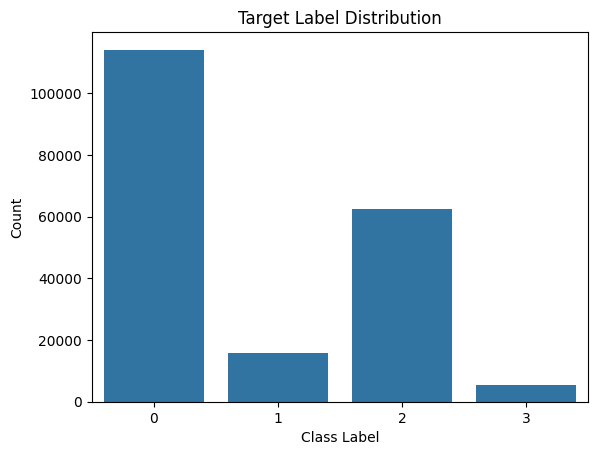

In [9]:
# Target Label Distribution

plt.figure()
sns.countplot(x='label', data=train_data)
plt.title("Target Label Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

# insights = class 0 is dominant category hence used class_Weight=balanced 
# in classifier

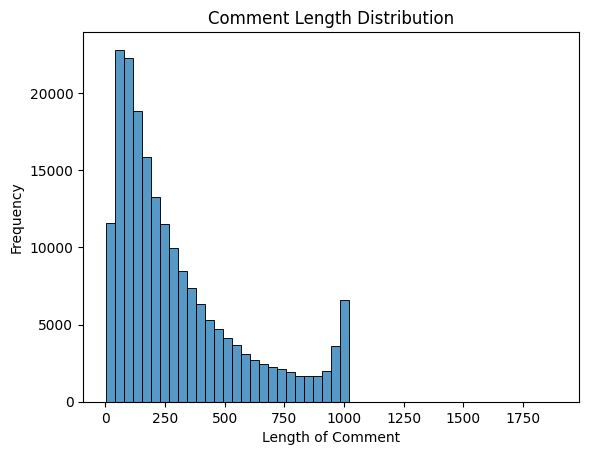

In [10]:
# Comment Length Analysis
train_data['comment_length'] = train_data['comment'].astype(str).apply(len)

plt.figure()
sns.histplot(train_data['comment_length'], bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Length of Comment")
plt.ylabel("Frequency")
plt.show()

# right skewed, comments shorter than 250chars, but spike at 1000char
# indicates limit at 1000 char

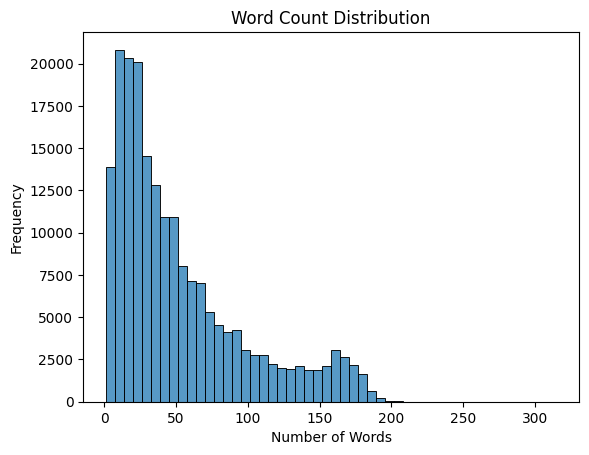

In [11]:
# word count distribution
train_data['word_count'] = train_data['comment'].astype(str).apply(lambda x: len(x.split()))

plt.figure()
sns.histplot(train_data['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

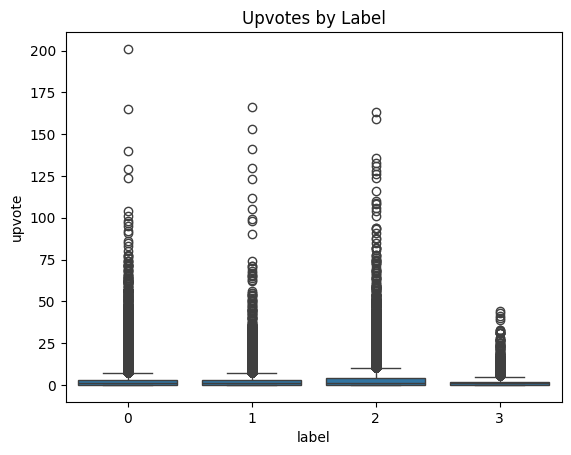

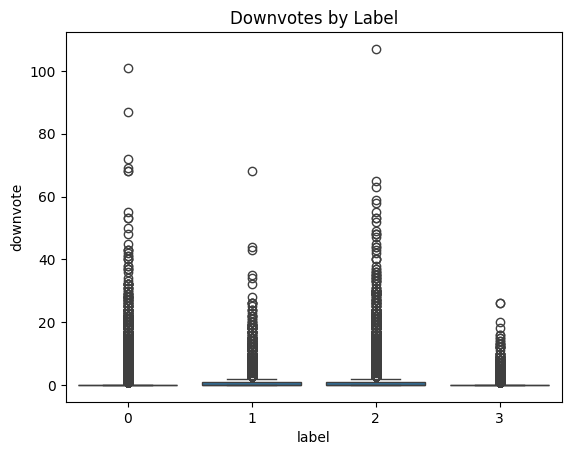

In [12]:
# Engagement Features vs Label
plt.figure()
sns.boxplot(x='label', y='upvote', data=train_data)
plt.title("Upvotes by Label")
plt.show()

plt.figure()
sns.boxplot(x='label', y='downvote', data=train_data)
plt.title("Downvotes by Label")
plt.show()

# helps determine controversioal comments
# intensity of reacion 
# 0=netural

#higher varieance higher agreeable comm

In [13]:
# upvotes 
# small no of comments get high engagement
# Comments in label 2 tend to generate more engagement / reactions

# downvotes
# label 2 highest variablity less outliers hihest enaggement for both

Text(0.5, 1.0, 'Feature Correlation Heatmap')

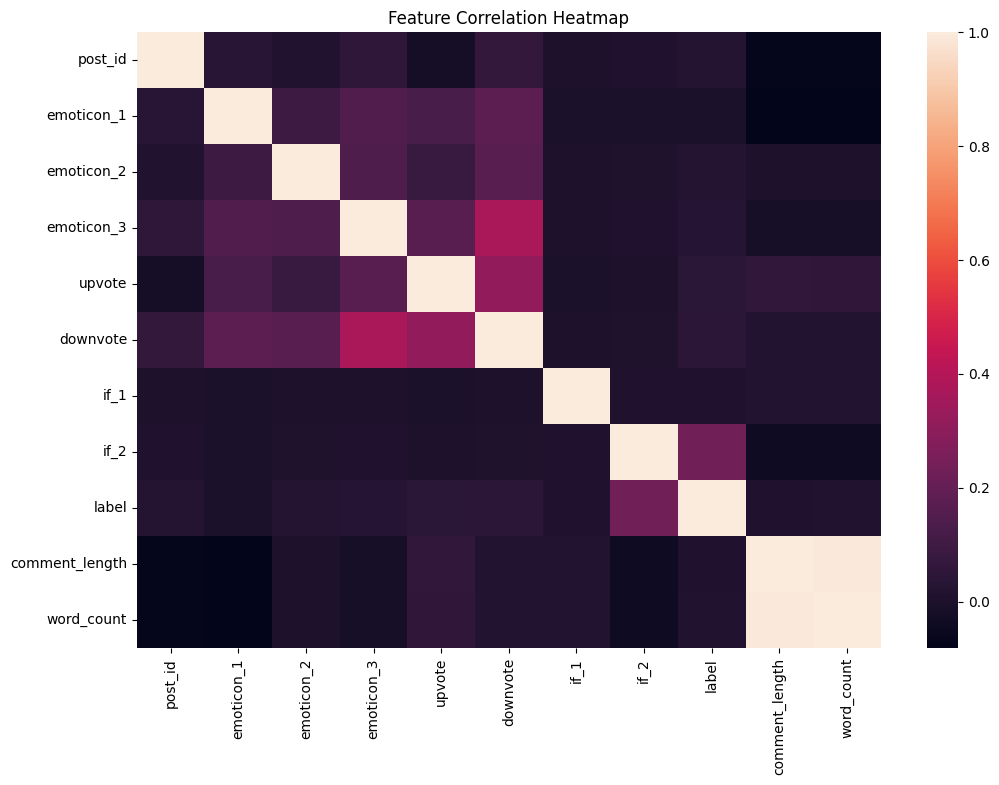

In [14]:
# correlation
numeric_cols = train_data.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=False)
plt.title("Feature Correlation Heatmap")
# comment length and word almost perfetcly correlated
# upvote downvote modertaly

In [15]:
plt.show()

# Data Cleaning

## Feature Definition

In [16]:
TARGET = "label"

text_col = "comment"

num_cols = [
    'comment_length','word_count',
    'log_upvote','log_downvote',
    'engagement_diff','engagement_ratio',
    'hour','weekday',
    'log_if_1','log_if_2',
    'avg_word_len',
    'exclamation_count',
    'question_count',
    'uppercase_ratio',
    'upvote_downvote_ratio',
     'engagement_total'
]

cat_cols = ['has_race','has_religion','has_gender']

bad_words = ['idiot','stupid','hate','kill','racist','dumb','moron']
kw_cols = [f'kw_{w}' for w in bad_words]

num_cols += [f'kw_{w}' for w in bad_words]

## FEature Engineering

In [17]:
def preprocess(df):
    df = df.copy()

    # text
    df['comment'] = df['comment'].fillna("")

    # presence flags
    for col in ['race', 'religion', 'gender']:
        df[f'has_{col}'] = df[col].notna().astype(int)

    # date
    df['created_date'] = pd.to_datetime(df['created_date'])
    df['hour'] = df['created_date'].dt.hour
    df['weekday'] = df['created_date'].dt.weekday
    df.drop(columns=['created_date'], inplace=True)

    # text
    df['comment_length'] = df['comment'].str.len()
    df['word_count'] = df['comment'].str.split().str.len()

    # nums
    df['log_upvote'] = np.log1p(df['upvote'])
    df['log_downvote'] = np.log1p(df['downvote']) 
# squashes outliers and normailizes distri
    
    df['engagement_diff'] = df['upvote'] - df['downvote']
    df['engagement_ratio'] = df['log_upvote'] / (df['log_downvote'] + 1)
#relative seniment of audience

    df['avg_word_len'] = df['comment_length'] / (df['word_count'] + 1)
    df['exclamation_count'] = df['comment'].str.count('!')
    df['question_count'] = df['comment'].str.count('\?')
    df['uppercase_ratio'] = df['comment'].str.count(r'[A-Z]') / (df['comment_length'] + 1)


    df['log_if_1'] = np.log1p(df['if_1'])
    df['log_if_2'] = np.log1p(df['if_2'])

    bad_words = ['idiot','stupid','hate','kill','racist','dumb','moron']

    for word in bad_words:
        df[f'kw_{word}'] = df['comment'].str.contains(word, case=False).astype(int)

    df['upvote_downvote_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['engagement_total'] = df['upvote'] + df['downvote']
    
    return df

In [18]:
train_data = preprocess(train_data)
test_data = preprocess(test_data)

# Training Validation Data

In [19]:
X = train_data.drop(columns=[TARGET])
y = train_data[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test = test_data.copy()

## Outiers handling

In [20]:
def cap_outliers_train(df, cols):
    bounds = {}
    for col in cols:
        q1 = df[col].quantile(0.01)
        q99 = df[col].quantile(0.99)
        bounds[col] = (q1, q99)
        df[col] = df[col].clip(q1, q99)
    return df, bounds

def apply_outliers(df, bounds):
    for col, (q1, q99) in bounds.items():
        df[col] = df[col].clip(q1, q99)
    return df

In [21]:
out_num_cols = ['log_upvote','log_downvote','comment_length','word_count']

X_train, bounds = cap_outliers_train(X_train, out_num_cols)
X_val = apply_outliers(X_val, bounds)
X_test = apply_outliers(X_test, bounds)

# Preprocessing

In [22]:
# Numeric pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Text pipelines
word_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_features=100000,
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    # ("svd", TruncatedSVD(n_components=300, random_state=42))
])

char_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3,5),
        max_features=50000,
        min_df=3,
    )),
    # ("svd", TruncatedSVD(n_components=200, random_state=42))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
    ("word", word_pipeline, text_col),
    ("char", char_pipeline, text_col)
])

X_train_final = preprocessor.fit_transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)

# Linear Models

In [23]:
model_scores = {}
trained_models = {}

In [24]:
def store_model(name, model, X_val, y_val, representation):
    pred = model.predict(X_val)
    
    f1 = f1_score(y_val, pred, average='macro')
    acc = accuracy_score(y_val, pred)
    
    model_scores[name] = f1
    trained_models[name] = (representation, model)
    
    print(f"\n{name} Performance:")
    print(f"F1 (Macro): {f1:.4f}")
    print(f"Accuracy : {acc:.4f}")

    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_val, pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Logistic


LR Base Performance:
F1 (Macro): 0.8158
Accuracy : 0.9101

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.74      0.80      0.77      3183
           2       0.87      0.91      0.89     12488
           3       0.65      0.65      0.65      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.82      0.82     39600
weighted avg       0.91      0.91      0.91     39600



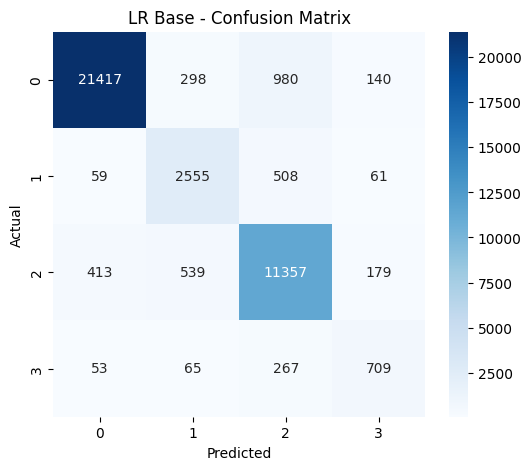


LR Tuned Performance:
F1 (Macro): 0.8135
Accuracy : 0.9073

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.70      0.84      0.77      3183
           2       0.88      0.89      0.88     12488
           3       0.57      0.75      0.65      1094

    accuracy                           0.91     39600
   macro avg       0.78      0.85      0.81     39600
weighted avg       0.92      0.91      0.91     39600



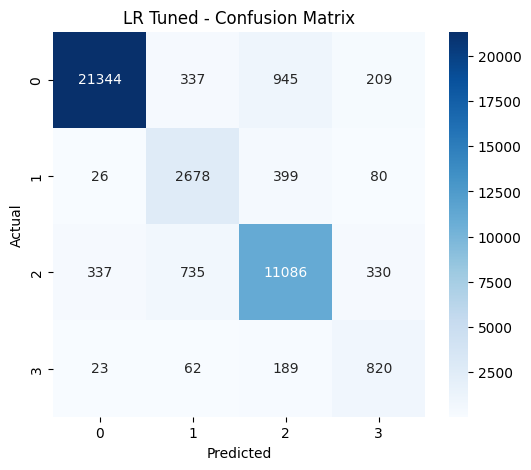

In [25]:
lr = LogisticRegression(
    solver = 'liblinear',
    # solver='lbfgs',
    # solver='saga',
    C=4.0,
    max_iter=5000, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

lr.fit(X_train_final, y_train)

store_model("LR Base", lr, X_val_final, y_val, "final")

# Tuning
lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42),
    {'C':[1,2,3,4]},
    scoring='f1_macro',
    # cv=3,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

lr_grid.fit(X_train_final, y_train)
store_model("LR Tuned", lr_grid.best_estimator_, X_val_final, y_val, "final")

## SGD


SGD Base Performance:
F1 (Macro): 0.7932
Accuracy : 0.9016

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.73      0.79      0.75      3183
           2       0.85      0.88      0.87     12488
           3       0.65      0.55      0.59      1094

    accuracy                           0.90     39600
   macro avg       0.80      0.79      0.79     39600
weighted avg       0.90      0.90      0.90     39600



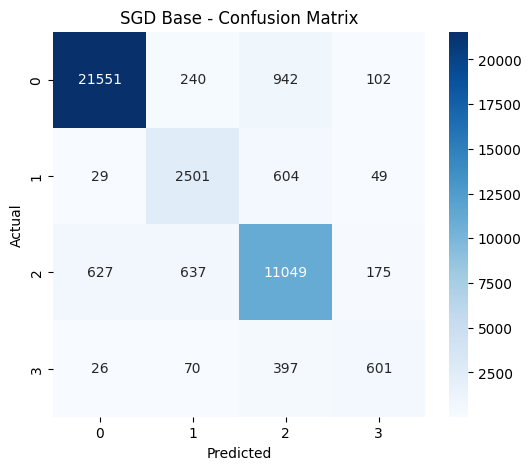


SGD Tuned Performance:
F1 (Macro): 0.8086
Accuracy : 0.9061

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.70      0.83      0.76      3183
           2       0.88      0.89      0.88     12488
           3       0.59      0.70      0.64      1094

    accuracy                           0.91     39600
   macro avg       0.78      0.84      0.81     39600
weighted avg       0.91      0.91      0.91     39600



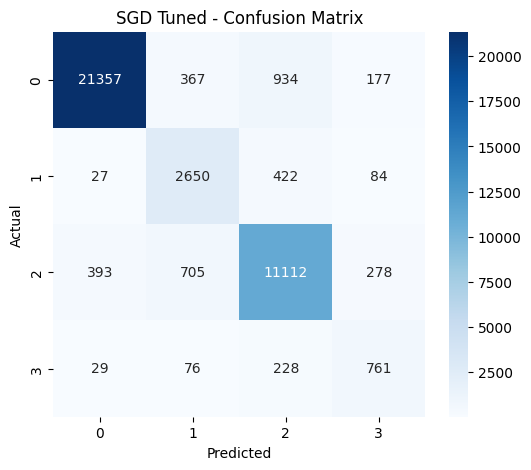

In [26]:
sgd = SGDClassifier(
    loss='log_loss', 
    # penalty='l2'
    class_weight='balanced', 
    random_state=42
)
sgd.fit(X_train_final, y_train)

store_model("SGD Base", sgd, X_val_final, y_val, "final")

sgd_grid = GridSearchCV(
    SGDClassifier(
        loss='log_loss', 
        class_weight='balanced',
        random_state=42
    ),
    {'alpha':[1e-5,1e-4,1e-3]},
    scoring='f1_macro',
    # cv=3,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

sgd_grid.fit(X_train_final, y_train)
store_model("SGD Tuned", sgd_grid.best_estimator_, X_val_final, y_val, "final")

## SVM


SVM Base Performance:
F1 (Macro): 0.7992
Accuracy : 0.8996

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22835
           1       0.73      0.78      0.75      3183
           2       0.86      0.89      0.88     12488
           3       0.65      0.60      0.62      1094

    accuracy                           0.90     39600
   macro avg       0.80      0.80      0.80     39600
weighted avg       0.90      0.90      0.90     39600



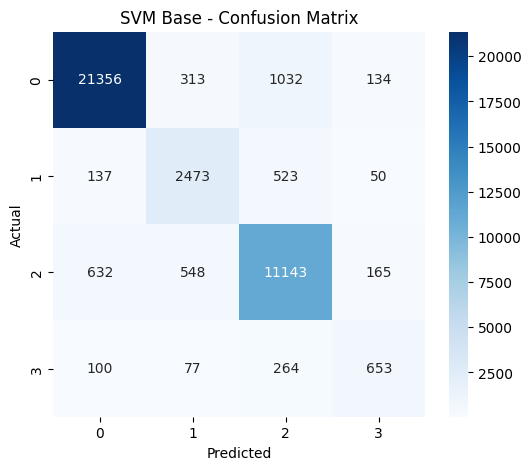

In [27]:
svm = LinearSVC(class_weight='balanced',random_state=42)
svm.fit(X_train_final, y_train)

store_model("SVM Base", svm, X_val_final, y_val, "final")

# svm_grid = GridSearchCV(
#     LinearSVC(
#         class_weight='balanced',
#         max_iter=5000,
#         random_state=42
#     ),
#     {'C':[1,1.5,2]},
#     scoring='f1_macro',
#     # cv=3,
#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     n_jobs=-1
# )

# svm_grid.fit(X_train_final, y_train)
# store_model("SVM Tuned", svm_grid.best_estimator_, X_val_final, y_val, "final")

## XGB

In [28]:
# from xgboost import XGBClassifier

# xgb = XGBClassifier(
#     n_estimators=1000,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     tree_method='hist',
#     random_state=42,
#     eval_metric='logloss'
# )

# xgb.fit(X_train_final, y_train)
# store_model("XGB", xgb, X_val_final, y_val, "final")

## Stacking

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Stacking Performance:
F1 (Macro): 0.8140
Accuracy : 0.9099

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.78      0.76      0.77      3183
           2       0.86      0.91      0.89     12488
           3       0.70      0.60      0.64      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.80      0.81     39600
weighted avg       0.91      0.91      0.91     39600



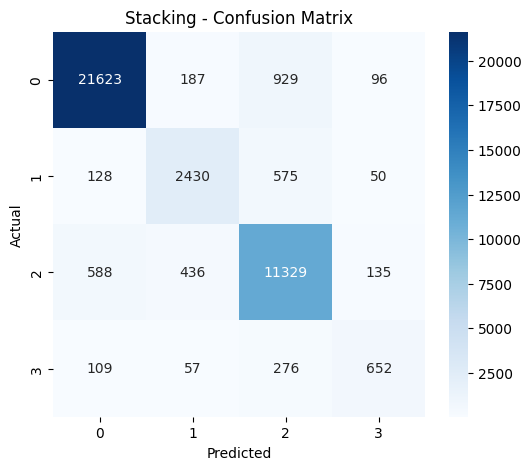

In [29]:
stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm),
        # ('xgb', xgb),
    ],
    final_estimator=LogisticRegression(
        C=3,
        max_iter=3000
    ),
    passthrough=True,
    n_jobs=-1
)

stack.fit(X_train_final, y_train)
store_model("Stacking", stack, X_val_final, y_val, "final")

# Model Performace

In [30]:
scores_df = (
    pd.DataFrame.from_dict(
        model_scores, 
        orient='index', 
        columns=['Macro_F1'])
    .sort_values(by='Macro_F1', ascending=False)
)

print("\nModel Performance Summary:")
display(scores_df)


Model Performance Summary:


,Macro_F1
LR Base,0.815754
Stacking,0.813950
LR Tuned,0.813531
SGD Tuned,0.808565
SVM Base,0.799184
SGD Base,0.793184


## Macro F1 score

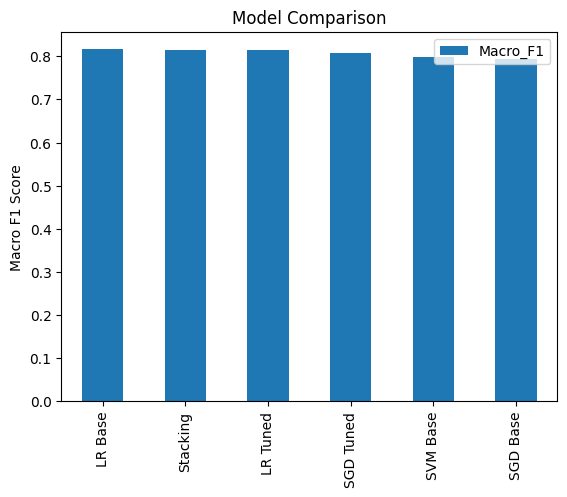

In [31]:
scores_df.plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Macro F1 Score")
plt.show()

# Submission
## Best model

In [32]:
best_model_name = scores_df.index[0]
best_representation, best_model = trained_models[best_model_name]

print(f"\nBest Model Selected: {best_model_name}")
print(f"Validation Macro F1: {scores_df.iloc[0]['Macro_F1']:.4f}")


Best Model Selected: LR Base
Validation Macro F1: 0.8158



Final Evaluation on Validation Set:
Accuracy: 0.910050505050505
F1 Macro: 0.815753986008671

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.74      0.80      0.77      3183
           2       0.87      0.91      0.89     12488
           3       0.65      0.65      0.65      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.82      0.82     39600
weighted avg       0.91      0.91      0.91     39600



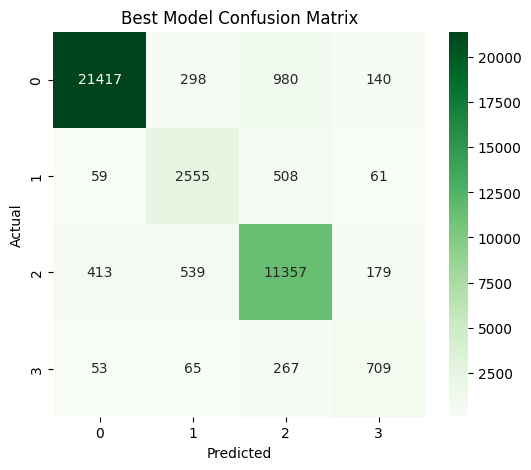

In [33]:
print("\nFinal Evaluation on Validation Set:")

val_preds = best_model.predict(X_val_final)

print("Accuracy:", accuracy_score(y_val, val_preds))
print("F1 Macro:", f1_score(y_val, val_preds, average='macro'))

print("\nClassification Report:")
print(classification_report(y_val, val_preds))

# Confusion Matrix
cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Best Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Submit prediction

In [34]:
if best_representation == 'final':
    test_preds = best_model.predict(X_test_final)


submission = pd.DataFrame({
    'ID': range(1, len(test_preds) + 1),
    'label': test_preds.astype(int)
})

submission.to_csv("submission.csv", index=False)
print("Submission saved as submission.csv")
submission.head()

Submission saved as submission.csv


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
